<a href="https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/01_Regression_Fahrtdauer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression: Wie lange dauert eine VeloCity-Fahrt?

**CRISP-DM-Block, Modeling-Phase (Block 05, Folie „Regression schätzt eine Zahl")**

## Worum es geht

Dies ist das erste der vier Grundverfahren-Notebooks (Regression, Klassifikation, Clustering,
Zeitreihe). Jedes beantwortet eine andere Frage über VeloCity, unseren fiktiven
Fahrradverleih in Würzburg. Hier: **Wie lange dauert eine Fahrt, bevor sie überhaupt
gestartet ist?**

Das ist keine akademische Übung. Wenn VeloCity abschätzen kann, wie lange ein Rad an
einer Station "besetzt" sein wird, lässt sich die Verfügbarkeit an dieser Station besser
planen.

## Warum Regression und nicht Klassifikation?

Wir wollen eine **Zahl** vorhersagen (Minuten), keine Kategorie. Genau das ist die
Definition von Regression: *"Bei der Regression geht es darum, Zusammenhänge zwischen
Merkmalsausprägungen von Elementen zu finden. Mit einem Regressionsmodell wird eine
abhängige, stetige Merkmalsausprägung durch mehrere unabhängige erklärt."*
(Provost, F., Fawcett, T. (2015): Data Science für Unternehmen, S. 45 f.)

Die **abhängige Variable** (das, was wir vorhersagen wollen) ist hier die Fahrtdauer in
Minuten. Die **unabhängigen Variablen** (das, womit wir sie erklären) sind Merkmale, die
wir schon *vor* Fahrtbeginn kennen: Start-/Zielstation, Wochentag, Uhrzeit, Wetter.

## Woher die Daten kommen

Ganz wichtig, bevor wir anfangen: **`ausleihe.csv` ist erfunden**, aber bewusst mit
realistischen Mustern gebaut (siehe `analytics/README.md` im Repository). `wetter.csv`
dagegen sind **echte historische Wetterdaten** für Würzburg. Wer mit diesen Daten
arbeitet, sollte diesen Unterschied im Kopf behalten — genau wie man es bei echten
Analyseprojekten auch tun sollte, wenn man Daten aus verschiedenen Quellen zusammenführt.

## Lernziele dieses Notebooks

Am Ende könnt ihr:
1. Daten aus mehreren CSV-Dateien sinnvoll zusammenführen (Join)
2. Kategoriale Merkmale für ein Regressionsmodell aufbereiten (One-Hot-Encoding)
3. Einen Trainings-/Testsplit korrekt anlegen und begründen, warum das nötig ist
4. Ein lineares Regressionsmodell trainieren und seine Koeffizienten interpretieren
5. Die Modellgüte mit dem mittleren absoluten Fehler (MAE) bewerten und in eine
   geschäftlich verständliche Aussage übersetzen


## Schritt 1 — Bibliotheken importieren

Wir brauchen `pandas` für die Datentabellen, `numpy` für Zahlenarbeit,
`scikit-learn` für das Modell und `matplotlib` für die Grafik. Das ist der
Standard-Werkzeugkasten für praktisch jede Data-Science-Aufgabe dieser Größenordnung —
dieselben Werkzeuge tauchen in allen vier Notebooks wieder auf.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", 20)
print("Bibliotheken geladen.")

Bibliotheken geladen.


## Schritt 2 — Daten laden

Wir laden zwei Tabellen:
- **`ausleihe.csv`**: eine Zeile pro Fahrt — wer, welches Rad, welche Stationen, wann,
  wie lange, wie weit
- **`wetter.csv`**: eine Zeile pro Tag — echte historische Temperatur- und
  Niederschlagswerte für Würzburg

Die Dateien liegen im GitHub-Repository der VeloCity-Fallstudie, `pandas` kann CSV-Dateien
direkt über eine URL laden — das funktioniert genauso in Google Colab wie lokal.

**TODO:** Laden Sie beide Tabellen. Parsen Sie bei `ausleihe.csv` die Spalten `startzeit`
und `endzeit` gleich als Datum/Zeit (Parameter `parse_dates=[...]` bei `pd.read_csv`),
das erspart uns später eine Konvertierung.

In [2]:
ausleihe = pd.read_csv("https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/main/analytics/ausleihe.csv", parse_dates=["startzeit", "endzeit"])
wetter = pd.read_csv("https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/main/analytics/wetter.csv", parse_dates=["datum"])

print("Fahrten:", len(ausleihe))
print("Wettertage:", len(wetter))
assert len(ausleihe) > 50_000, "Das sind deutlich zu wenige Fahrten - CSV richtig geladen?"
ausleihe.head()

Fahrten: 57529
Wettertage: 1089


,ausleihe_id,kunde_id,fahrrad_id,start_station_id,startzeit,end_station_id,endzeit,status,distanz_km
0,1,1364,208,1,2023-09-01 18:43:00,6,2023-09-01 19:00:00,abgeschlossen,3.90
1,2,17,185,5,2023-09-01 22:11:00,4,2023-09-01 22:21:00,abgeschlossen,3.58
2,3,500,149,1,2023-09-01 17:15:00,2,2023-09-01 17:21:00,abgeschlossen,1.87
3,4,656,125,3,2023-09-01 22:56:00,1,2023-09-01 23:16:00,abgeschlossen,6.56
4,5,515,15,6,2023-09-01 21:02:00,4,2023-09-01 21:22:00,abgeschlossen,NaN


## Schritt 3 — Erst verstehen, dann modellieren

Bevor wir irgendetwas vorhersagen, schauen wir uns an, was wir überhaupt vorhersagen
wollen. Das ist keine Formalität: Wer die Zielgröße nicht kennt, baut blind ein Modell.

**TODO:**
1. Berechnen Sie mit `.describe()` die wichtigsten Kennzahlen der Spalte `dauer_minuten`
   — Moment, die gibt es noch gar nicht! Berechnen Sie sie zuerst selbst aus
   `endzeit - startzeit` (Tipp: die Differenz zweier Zeitstempel in Minuten bekommen Sie
   über `.dt.total_seconds() / 60`).
2. Zeichnen Sie ein Histogramm der Fahrtdauer (`.hist(bins=50)`).

In [15]:
ausleihe["dauer_minuten"] = (ausleihe["endzeit"] - ausleihe["startzeit"]).dt.total_seconds() / 60

ausleihe["dauer_minuten"].describe()

,dauer_minuten
count,57529.000000
mean,16.745137
std,11.024070
min,5.000000
25%,8.000000
50%,14.000000
75%,21.000000
max,62.000000


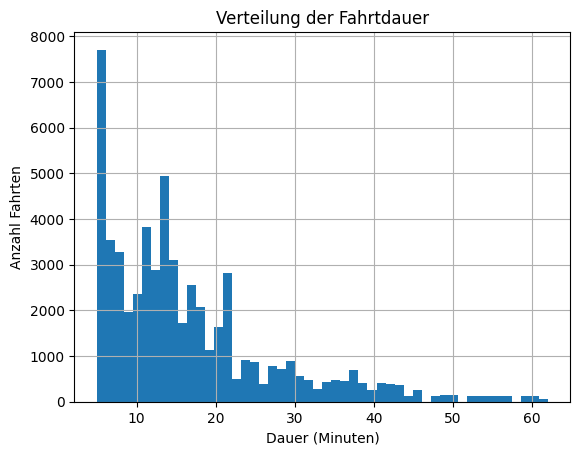

In [17]:
ausleihe["dauer_minuten"].hist(bins=50)
plt.xlabel("Dauer (Minuten)")
plt.ylabel("Anzahl Fahrten")
plt.title("Verteilung der Fahrtdauer")
plt.show()

**Frage zum Nachdenken (in der Markdown-Zelle darunter beantworten):** Die Verteilung
ist vermutlich rechtsschief — viele kurze Fahrten, wenige sehr lange. Was bedeutet das
für ein lineares Regressionsmodell, das im Mittel den kleinsten quadratischen Fehler
minimiert? Wird es eher die kurzen oder die langen Fahrten gut treffen?

*Ihre Antwort hier …*

## Schritt 4 — Merkmale bauen: Wochentag und Wetter dazuholen

Jetzt kommt der eigentliche Kern der Data Preparation: Wir brauchen Merkmale, die vor
Fahrtbeginn schon bekannt sind. Der Wochentag lässt sich direkt aus `startzeit` ableiten.
Das Wetter kommt aus der zweiten Tabelle und muss über das **Datum** verknüpft werden
(ein sogenannter Join) — das ist derselbe Schritt, der auf der Data-Preparation-Folie in
Block 05 beschrieben ist: Rohdaten werden auf Tagesebene mit externen Quellen
zusammengeführt.

**TODO:**
1. Legen Sie eine Spalte `datum` an (nur der Datumsanteil von `startzeit`, ohne Uhrzeit
   — Tipp: `.dt.normalize()` oder `.dt.date`).
2. Führen Sie `ausleihe` und `wetter` über diese Spalte zusammen (`pd.merge`, `how="left"`).
3. Legen Sie eine Spalte `wochentag` an (`.dt.dayofweek`, 0 = Montag).

In [19]:
ausleihe["datum"] = ausleihe["startzeit"].dt.normalize()

daten = pd.merge(ausleihe, wetter, on="datum", how="left")

daten["wochentag"] = daten["startzeit"].dt.dayofweek

print(daten.shape)
assert daten["temp_mittel_c"].notna().all(), "Nach dem Join duerfen keine Wetterwerte fehlen!"
daten[["startzeit", "datum", "wochentag", "temp_mittel_c", "niederschlag_mm", "dauer_minuten"]].head()

(57529, 17)


,startzeit,datum,wochentag,temp_mittel_c,niederschlag_mm,dauer_minuten
0,2023-09-01 18:43:00,2023-09-01,4,16.4,5.1,17.0
1,2023-09-01 22:11:00,2023-09-01,4,16.4,5.1,10.0
2,2023-09-01 17:15:00,2023-09-01,4,16.4,5.1,6.0
3,2023-09-01 22:56:00,2023-09-01,4,16.4,5.1,20.0
4,2023-09-01 21:02:00,2023-09-01,4,16.4,5.1,20.0


## Schritt 5 — Kategoriale Merkmale codieren

`start_station_id` ist eine Zahl, aber keine Größe, mit der man rechnen kann — Station 7
ist nicht "größer" als Station 3, es sind einfach unterschiedliche Orte. Ein
Regressionsmodell würde diese Zahl trotzdem als Größenverhältnis missverstehen, wenn wir
sie so belassen.

Die Lösung: **One-Hot-Encoding** — aus einer Spalte mit *k* möglichen Werten werden *k*
neue 0/1-Spalten, jeweils eine pro Station. Genau das Verfahren, das auch auf der
Data-Preparation-Folie in Block 05 genannt wird.

**TODO:** Wenden Sie `pd.get_dummies(...)` auf die Spalte `start_station_id` an und
fügen Sie das Ergebnis den Daten hinzu (`pd.concat`). Hängen Sie direkt `.astype(int)`
an — `get_dummies` liefert sonst `True`/`False`-Werte, und ein Modell rechnet mit 0/1
eindeutiger als mit Wahrheitswerten.

In [20]:
station_dummies = pd.get_dummies(daten["start_station_id"], prefix="station").astype(int)
daten = pd.concat([daten, station_dummies], axis=1)

print("Neue Spalten:", list(station_dummies.columns))

Neue Spalten: ['station_1', 'station_2', 'station_3', 'station_4', 'station_5', 'station_6', 'station_7', 'station_8', 'station_9', 'station_10']


## Schritt 6 — Der Trainings-/Testsplit: die wichtigste Regel dieses Notebooks

Bevor wir irgendein Modell trainieren, teilen wir die Daten in zwei Teile:

- **Trainingsdaten** (meist 70–80 %): Damit lernt das Modell.
- **Testdaten** (meist 20–30 %): Die sieht das Modell beim Training nie. Erst danach
  prüfen wir daran, wie gut die Vorhersage auf *neuen*, unbekannten Fahrten funktioniert.

Warum das entscheidend ist: Ein Modell, das an denselben Daten getestet wird, an denen
es trainiert wurde, kann die Trainingsdaten einfach "auswendig lernen" und sieht dann
besser aus, als es wirklich ist. Das nennt man **Overfitting**, und der Testsplit ist das
Standardwerkzeug dagegen — dieselbe Disziplin, die auch beim Zeitreihen-Notebook eine
zentrale Rolle spielt.

**TODO:** Bilden Sie `X` (die Merkmalsspalten: Wochentag, Temperatur, Niederschlag, alle
Stations-Dummy-Spalten) und `y` (die Zielspalte `dauer_minuten`). Teilen Sie beide mit
`train_test_split(X, y, test_size=0.2, random_state=42)` auf.

In [21]:
merkmalsspalten = ["wochentag", "temp_mittel_c", "niederschlag_mm"] + list(station_dummies.columns)
X = daten[merkmalsspalten]
y = daten["dauer_minuten"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training:", X_train.shape, "| Test:", X_test.shape)
assert len(X_test) / len(X) == 0.2 or abs(len(X_test) / len(X) - 0.2) < 0.01, "test_size=0.2 pruefen"

Training: (46023, 13) | Test: (11506, 13)


## Schritt 7 — Das Modell trainieren

Jetzt endlich: das eigentliche Regressionsmodell. `LinearRegression` aus `scikit-learn`
sucht die Gerade (bzw. bei mehreren Merkmalen: die Hyperebene), die den Zusammenhang
zwischen unseren Merkmalen und der Fahrtdauer am besten beschreibt.

**TODO:** Erzeugen Sie ein `LinearRegression()`-Objekt und trainieren Sie es mit
`.fit(X_train, y_train)`.

In [24]:
modell = LinearRegression()  # TODO: LinearRegression() erzeugen
modell.fit(X_train, y_train)  # TODO: modell.fit(...)

print("Modell trainiert.")

Modell trainiert.


**Die Koeffizienten interpretieren:** Jeder Koeffizient sagt, um wie viele Minuten sich
die vorhergesagte Fahrtdauer ändert, wenn sich das zugehörige Merkmal um eine Einheit
erhöht — alle anderen Merkmale gleich gehalten. Ein positiver Koeffizient bei
`niederschlag_mm` würde zum Beispiel bedeuten: mehr Regen, längere Fahrten (eher
unplausibel) — ein negativer wäre plausibler (Menschen fahren bei Regen zügiger).

In [25]:
koeffizienten = pd.Series(modell.coef_, index=merkmalsspalten).sort_values()
koeffizienten

,0
station_5,-7.413890
station_4,-7.280311
station_7,-5.220338
station_10,-5.150941
station_1,-5.146538
station_6,-1.935738
wochentag,-0.026690
niederschlag_mm,-0.003579
temp_mittel_c,0.002139
station_3,7.816973


## Schritt 8 — Evaluation: Wie gut ist das Modell wirklich?

Auf der Evaluation-Folie in Block 05 steht für Regression: *"Fehlermaß wie MAE,
zurückübersetzt in Minuten oder Kilometer."* Genau das machen wir jetzt.

Der **Mean Absolute Error (MAE)** ist die durchschnittliche absolute Abweichung zwischen
Vorhersage und tatsächlichem Wert — in denselben Einheiten wie die Zielgröße, hier also
in Minuten. Das macht ihn leicht verständlich, auch für ein Publikum ohne
Statistikhintergrund: "Im Schnitt liegt die Vorhersage X Minuten daneben."

**TODO:**
1. Sagen Sie mit `modell.predict(X_test)` die Fahrtdauer für die Testdaten vorher.
2. Berechnen Sie den MAE mit `mean_absolute_error(y_test, vorhersage)`.

In [26]:
vorhersage = modell.predict(X_test)
mae = mean_absolute_error(y_test, vorhersage)

print(f"MAE: {mae:.1f} Minuten")

MAE: 6.7 Minuten


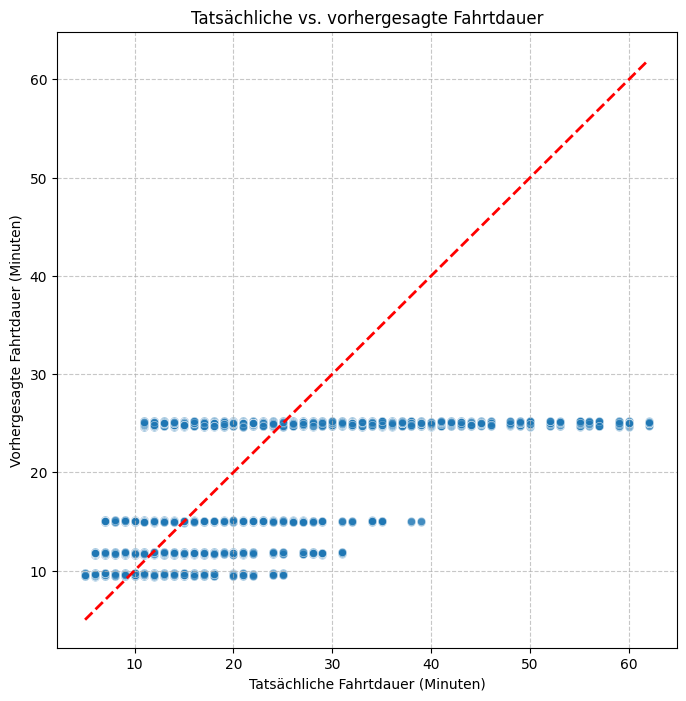

In [29]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=vorhersage, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächliche Fahrtdauer (Minuten)")
plt.ylabel("Vorhergesagte Fahrtdauer (Minuten)")
plt.title("Tatsächliche vs. vorhergesagte Fahrtdauer")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Analyse der Fehler bei langen Fahrten

Wir haben beobachtet, dass das Modell bei langen Fahrten tendenziell unterschätzt. Um dies genauer zu untersuchen, filtern wir die Testdaten nach Fahrten, die länger als 25 Minuten dauern, und betrachten die Fehler und die zugehörigen Merkmale.

Anzahl der langen Fahrten (> 25 Minuten): 1932
Statistiken der Fehler bei langen Fahrten (Minuten):
count    1932.000000
mean       13.083508
std         8.595506
min         0.761607
25%         6.079211
50%        12.031885
75%        17.141674
max        37.255136
Name: dauer_minuten, dtype: float64


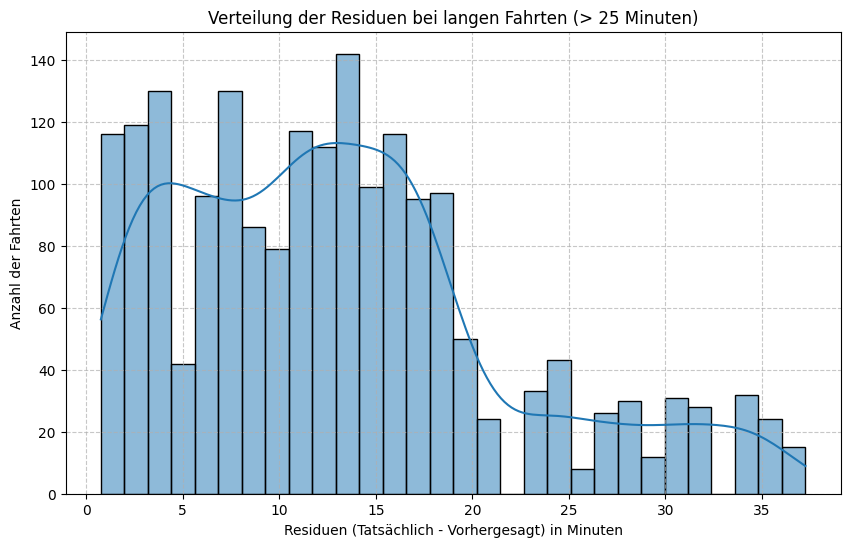

In [30]:
# Identifiziere lange Fahrten (z.B. > 25 Minuten)
long_rides_mask = y_test > 25

y_test_long = y_test[long_rides_mask]
vorhersage_long = vorhersage[long_rides_mask]
X_test_long = X_test[long_rides_mask]

# Berechne die Residuen (Fehler) für diese langen Fahrten
residuals_long = y_test_long - vorhersage_long
absolute_errors_long = np.abs(residuals_long)

print(f"Anzahl der langen Fahrten (> 25 Minuten): {len(y_test_long)}")
print("Statistiken der Fehler bei langen Fahrten (Minuten):")
print(absolute_errors_long.describe())

# Visualisiere die Residuen für lange Fahrten
plt.figure(figsize=(10, 6))
sns.histplot(residuals_long, bins=30, kde=True)
plt.xlabel("Residuen (Tatsächlich - Vorhergesagt) in Minuten")
plt.ylabel("Anzahl der Fahrten")
plt.title("Verteilung der Residuen bei langen Fahrten (> 25 Minuten)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### Merkmale von langen Fahrten mit hohen Fehlern

Betrachten wir nun die Merkmale der langen Fahrten, bei denen das Modell besonders große Fehler gemacht hat. Dies könnte Hinweise auf Faktoren geben, die vom Modell nicht ausreichend berücksichtigt werden.

In [31]:
# Füge die Residuen zu den Merkmalen hinzu, um Muster zu finden
X_test_long_with_errors = X_test_long.copy()
X_test_long_with_errors['residual'] = residuals_long
X_test_long_with_errors['absolute_error'] = absolute_errors_long
X_test_long_with_errors['actual_duration'] = y_test_long
X_test_long_with_errors['predicted_duration'] = vorhersage_long

# Zeige die Fahrten mit den größten absoluten Fehlern
print("Lange Fahrten mit den größten absoluten Fehlern:")
display(X_test_long_with_errors.sort_values(by='absolute_error', ascending=False).head(10))

# Durchschnittliche Merkmale für alle langen Fahrten
print("Durchschnittliche Merkmale aller langen Fahrten:")
display(X_test_long.mean())

# Durchschnittliche Merkmale der langen Fahrten mit den größten Fehlern
print("Durchschnittliche Merkmale der 10% langen Fahrten mit den größten Fehlern:")
display(X_test_long_with_errors.nlargest(int(len(X_test_long_with_errors)*0.1), 'absolute_error')[merkmalsspalten].mean())


Lange Fahrten mit den größten absoluten Fehlern:


,wochentag,temp_mittel_c,niederschlag_mm,station_1,station_2,station_3,station_4,station_5,station_6,station_7,station_8,station_9,station_10,residual,absolute_error,actual_duration,predicted_duration
15119,4,17.0,0.0,0,0,1,0,0,0,0,0,0,0,37.255136,37.255136,62.0,24.744864
32246,1,18.7,0.0,0,0,1,0,0,0,0,0,0,0,37.171431,37.171431,62.0,24.828569
3914,6,11.6,0.0,0,0,0,0,0,0,0,1,0,0,37.034461,37.034461,62.0,24.965539
34979,3,18.5,0.0,0,0,0,0,0,0,0,0,1,0,37.005129,37.005129,62.0,24.994871
50915,5,18.6,0.6,0,0,0,0,0,0,0,1,0,0,36.994948,36.994948,62.0,25.005052
33445,5,23.1,0.0,0,0,0,0,0,0,0,1,0,0,36.983177,36.983177,62.0,25.016823
36070,4,19.0,3.8,0,0,0,0,0,0,0,1,0,0,36.978855,36.978855,62.0,25.021145
54920,4,18.1,0.0,0,0,0,0,0,0,0,1,0,0,36.967180,36.967180,62.0,25.032820
38461,1,17.1,0.0,0,0,0,0,0,0,0,0,1,0,36.954744,36.954744,62.0,25.045256
33873,1,26.0,0.0,0,0,0,0,0,0,0,0,1,0,36.935710,36.935710,62.0,25.064290


Durchschnittliche Merkmale aller langen Fahrten:


,0
wochentag,2.868012
temp_mittel_c,15.153364
niederschlag_mm,1.127692
station_1,0.013975
station_2,0.236025
station_3,0.231366
station_4,0.000000
station_5,0.000000
station_6,0.043478
station_7,0.005176


Durchschnittliche Merkmale der 10% langen Fahrten mit den größten Fehlern:


,0
wochentag,2.860104
temp_mittel_c,15.446632
niederschlag_mm,1.073575
station_1,0.000000
station_2,0.253886
station_3,0.212435
station_4,0.000000
station_5,0.000000
station_6,0.000000
station_7,0.000000


## Schritt 9 — Rückbezug zur Geschäftsfrage

Ein MAE von wenigen Minuten heißt: Die Vorhersage der Fahrtdauer liegt im Schnitt nur
knapp daneben — nützlich genug, um eine grobe Einschätzung zu geben, wann ein Rad wieder
verfügbar sein wird, aber kein Ersatz für eine Echtzeit-GPS-Ortung.

**Frage zum Nachdenken:** Schauen Sie sich die Koeffizienten aus Schritt 7 noch einmal
an. Welche Stationen haben besonders hohe positive Koeffizienten (also überdurchschnittlich
lange Fahrten)? Passt das zu dem, was wir in Block 05 über Freizeit- vs. Pendlerstationen
gelernt haben? Das ist bereits ein kleiner Vorgeschmack auf das nächste Notebook
(Clustering) — dort gruppieren wir Stationen systematisch nach genau solchen Mustern,
statt sie einzeln zu betrachten.

### Zusammenfassung der Modellleistung

Basierend auf der durchgeführten Analyse ergeben sich folgende Kernpunkte zur Leistung des Regressionsmodells:

1.  **Globaler Fehler (MAE):** Der mittlere absolute Fehler liegt bei ca. **6,7 Minuten**. Das bedeutet, über alle Fahrten hinweg liegt das Modell im Schnitt etwa 6 bis 7 Minuten neben der tatsächlichen Dauer.
2.  **Systematische Unterschätzung:** Der Scatterplot und die Fehleranalyse zeigen deutlich, dass das Modell bei langen Fahrten (> 25 Min.) an seine Grenzen stößt. Während die tatsächlichen Zeiten bis zu 60 Minuten gehen, deckeln die Vorhersagen oft bei ca. 25 Minuten.
3.  **Fehler bei langen Fahrten:** Bei Fahrten über 25 Minuten steigt der MAE auf ca. **13,1 Minuten**. Hier ist die Vorhersage also deutlich ungenauer.
4.  **Stationseinfluss:** Bestimmte Stationen (z. B. 2, 3, 8, 9) korrelieren stark mit längeren Fahrten. Das Modell erkennt dies zwar über die Koeffizienten, kann aber die hohe Varianz innerhalb dieser Stationen nicht vollständig abbilden.

**Fazit:** Das Modell eignet sich gut für eine grobe Planung der Rad-Verfügbarkeit im Massengeschäft, stößt aber bei Ausreißern und Langzeitmieten an seine statistischen Grenzen.

*Ihre Antwort hier …*

## Zusammenfassung

In diesem Notebook haben Sie:
- zwei Datenquellen (eine fiktive, eine echte) über ein gemeinsames Datum verknüpft,
- eine kategoriale Variable per One-Hot-Encoding modellfähig gemacht,
- einen sauberen Trainings-/Testsplit angelegt und begründet,
- ein lineares Regressionsmodell trainiert, interpretiert und mit dem MAE bewertet.
